In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pylab as plt
from scipy.optimize import least_squares

## Import Dataset

In [76]:
sheets = pd.ExcelFile('Swap and Swaption Markets_Amended.xlsx').sheet_names

In [77]:
df_swaption = pd.read_excel('Swap and Swaption Markets_Amended.xlsx', sheet_name=sheets[3], header = 2)
df_swaption

,Expiry,Tenor,-200bps,-150bps,-100bps,-50bps,-25bps,ATM,+25bps,+50bps,+100bps,+150bps,+200bps
0,1Y,1Y,91.570,62.030,44.130,31.224,26.182,22.50,20.96,21.40,24.34,27.488,30.297
1,1Y,2Y,83.270,61.240,46.570,35.807,31.712,28.72,27.12,26.84,28.51,31.025,33.523
2,1Y,3Y,73.920,56.870,44.770,35.745,32.317,29.78,28.29,27.80,28.77,30.725,32.833
3,1Y,5Y,55.190,44.640,36.510,30.242,27.851,26.07,24.98,24.56,25.12,26.536,28.165
4,1Y,10Y,41.180,35.040,30.207,26.619,25.351,24.47,23.98,23.82,24.25,25.204,26.355
5,5Y,1Y,67.800,49.090,38.400,31.485,29.060,27.26,26.04,25.32,24.94,25.320,25.980
6,5Y,2Y,57.880,46.410,39.033,33.653,31.531,29.83,28.56,27.65,26.71,26.540,26.760
7,5Y,3Y,53.430,44.440,38.180,33.437,31.536,29.98,28.76,27.82,26.67,26.200,26.150
8,5Y,5Y,41.990,36.524,32.326,29.005,27.677,26.60,25.73,25.02,24.06,23.570,23.400
9,5Y,10Y,34.417,30.948,28.148,25.954,25.136,24.51,23.99,23.56,22.91,22.490,22.250


Notes on Swaption Data on first inspection:
* This is lognormal Implied Vol for SOFR Swaptions
* Convection for bps strike is (Forward + Basis Point)

In [78]:
def convert_tenor_to_numeric(series):
    num = series.str.slice(stop = -1).astype(int)
    freq = series.str.slice(start = -1)

    conditions = [freq.str.upper() == 'M', freq.str.upper() == 'Y']
    choices = [num * 30 / 360, num.astype(float)]

    return pd.Series(np.select(conditions, choices, default=np.nan), name=series.name)

In [79]:
def convert_bps_to_numeric(column_series):

    column_names = column_series.str.slice(stop = -3)
    replaced_list = []

    for col in column_names:
        if col == '':
            replaced_list.append(0.0)
        else:
            replaced_list.append(float(col) / 10000)
    
    return replaced_list  

In [92]:
# Extract the expiry and tenor information from the column names and convert them to numeric values
# Imp vol is calculated in percentages, so we need to divide by 100 to get the decimal form
# bps is defined as 1/100 of a percentage point, so we need to divide by 10000 to get the decimal form

df_timings = pd.concat([convert_tenor_to_numeric(df_swaption['Expiry']), convert_tenor_to_numeric(df_swaption['Tenor'])], axis=1)
df_bps = df_swaption.drop(columns = ['Expiry', 'Tenor']) / 100  # e.g. 22.5 -> 0.225
df_bps.columns = convert_bps_to_numeric(df_bps.columns)

display(pd.concat([df_timings, df_bps], axis=1))

,Expiry,Tenor,-0.02,-0.015,-0.01,-0.005,-0.0025,0.0,0.0025,0.005,0.01,0.015,0.02
0,1.0,1.0,0.91570,0.62030,0.44130,0.31224,0.26182,0.2250,0.2096,0.2140,0.2434,0.27488,0.30297
1,1.0,2.0,0.83270,0.61240,0.46570,0.35807,0.31712,0.2872,0.2712,0.2684,0.2851,0.31025,0.33523
2,1.0,3.0,0.73920,0.56870,0.44770,0.35745,0.32317,0.2978,0.2829,0.2780,0.2877,0.30725,0.32833
3,1.0,5.0,0.55190,0.44640,0.36510,0.30242,0.27851,0.2607,0.2498,0.2456,0.2512,0.26536,0.28165
4,1.0,10.0,0.41180,0.35040,0.30207,0.26619,0.25351,0.2447,0.2398,0.2382,0.2425,0.25204,0.26355
5,5.0,1.0,0.67800,0.49090,0.38400,0.31485,0.29060,0.2726,0.2604,0.2532,0.2494,0.25320,0.25980
6,5.0,2.0,0.57880,0.46410,0.39033,0.33653,0.31531,0.2983,0.2856,0.2765,0.2671,0.26540,0.26760
7,5.0,3.0,0.53430,0.44440,0.38180,0.33437,0.31536,0.2998,0.2876,0.2782,0.2667,0.26200,0.26150
8,5.0,5.0,0.41990,0.36524,0.32326,0.29005,0.27677,0.2660,0.2573,0.2502,0.2406,0.23570,0.23400
9,5.0,10.0,0.34417,0.30948,0.28148,0.25954,0.25136,0.2451,0.2399,0.2356,0.2291,0.22490,0.22250


We can also output the actual prices of the swaptions using the Black Scholes Lognormal model, which is the same as the Black76 model for swaptions.

In [93]:
## Default Functions for Black Scholes Lognormal Model. 
## In the event of a Black76 model, set S = F and r = 0.0.
## If there is dividend, set r = r-q where q is the dividend yield.

def BlackScholesLognormalPayer(S, K, r, sigma, T):
    d1 = (np.log(S/K)+(r+sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def BlackScholesLognormalReceiver(S, K, r, sigma, T):
    d1 = (np.log(S/K)+(r+sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

In [ ]:
# Build combined surface
df_surface = pd.concat([df_timings, df_bps], axis=1)

# Assumptions for pricing from available data only
F = 1.0          # normalized forward swap rate
r = 0.0          # Black76 discounting convention
annuity = 1.0    # normalized PVBP/annuity

strike_shifts = df_bps.columns.astype(float).tolist()
T_vec = df_timings['Expiry'].astype(float).values

# Price payer (call) and receiver (put) swaptions
payer_prices = pd.DataFrame(index=df_bps.index, columns=df_bps.columns, dtype=float)
receiver_prices = pd.DataFrame(index=df_bps.index, columns=df_bps.columns, dtype=float)

for shift in strike_shifts:
    K = F + shift
    vols = df_bps[shift].astype(float).values

    payer_prices[shift] = [
        annuity * BlackScholesLognormalPayer(F, K, r, sigma, T)
        for sigma, T in zip(vols, T_vec)
    ]
    receiver_prices[shift] = [
        annuity * BlackScholesLognormalReceiver(F, K, r, sigma, T)
        for sigma, T in zip(vols, T_vec)
    ]

# Attach expiry/tenor for readability
df_payer_swaption_prices = pd.concat([df_timings, payer_prices], axis=1)
df_receiver_swaption_prices = pd.concat([df_timings, receiver_prices], axis=1)

display(df_payer_swaption_prices)
display(df_receiver_swaption_prices)

,Expiry,Tenor,-0.02,-0.015,-0.01,-0.005,-0.0025,0.0,0.0025,0.005,0.01,0.015,0.02
0,1.0,1.0,0.359490,0.249296,0.178806,0.126267,0.105278,0.089573,0.082326,0.082947,0.092429,0.102797,0.111869
1,1.0,2.0,0.329706,0.246314,0.188243,0.144248,0.127081,0.114184,0.106752,0.104541,0.108990,0.116844,0.124677
2,1.0,3.0,0.295538,0.229755,0.181284,0.144006,0.129461,0.118367,0.111381,0.108344,0.110021,0.115654,0.121940
3,1.0,5.0,0.225380,0.182894,0.149179,0.122406,0.111867,0.103710,0.098276,0.095499,0.095530,0.099012,0.103389
4,1.0,10.0,0.171691,0.145662,0.124517,0.108136,0.101994,0.097378,0.094312,0.092562,0.092071,0.093711,0.096183
5,5.0,1.0,0.556089,0.421296,0.335673,0.276990,0.255677,0.239463,0.228091,0.220955,0.215763,0.217137,0.220955
6,5.0,2.0,0.487671,0.400722,0.340789,0.295043,0.276464,0.261250,0.249574,0.240897,0.230981,0.227646,0.227680
7,5.0,3.0,0.455296,0.385393,0.333891,0.293252,0.276506,0.262516,0.251271,0.242346,0.230638,0.224721,0.222422
8,5.0,5.0,0.367725,0.322157,0.285826,0.256150,0.243960,0.233837,0.225436,0.218376,0.208165,0.201991,0.198595
9,5.0,10.0,0.306711,0.276196,0.250809,0.230255,0.222287,0.215939,0.210484,0.205793,0.198207,0.192605,0.188574


,Expiry,Tenor,-0.02,-0.015,-0.01,-0.005,-0.0025,0.0,0.0025,0.005,0.01,0.015,0.02
0,1.0,1.0,0.339490,0.234296,0.168806,0.121267,0.102778,0.089573,0.084826,0.087947,0.102429,0.117797,0.131869
1,1.0,2.0,0.309706,0.231314,0.178243,0.139248,0.124581,0.114184,0.109252,0.109541,0.118990,0.131844,0.144677
2,1.0,3.0,0.275538,0.214755,0.171284,0.139006,0.126961,0.118367,0.113881,0.113344,0.120021,0.130654,0.141940
3,1.0,5.0,0.205380,0.167894,0.139179,0.117406,0.109367,0.103710,0.100776,0.100499,0.105530,0.114012,0.123389
4,1.0,10.0,0.151691,0.130662,0.114517,0.103136,0.099494,0.097378,0.096812,0.097562,0.102071,0.108711,0.116183
5,5.0,1.0,0.536089,0.406296,0.325673,0.271990,0.253177,0.239463,0.230591,0.225955,0.225763,0.232137,0.240955
6,5.0,2.0,0.467671,0.385722,0.330789,0.290043,0.273964,0.261250,0.252074,0.245897,0.240981,0.242646,0.247680
7,5.0,3.0,0.435296,0.370393,0.323891,0.288252,0.274006,0.262516,0.253771,0.247346,0.240638,0.239721,0.242422
8,5.0,5.0,0.347725,0.307157,0.275826,0.251150,0.241460,0.233837,0.227936,0.223376,0.218165,0.216991,0.218595
9,5.0,10.0,0.286711,0.261196,0.240809,0.225255,0.219787,0.215939,0.212984,0.210793,0.208207,0.207605,0.208574


There are two ways to calibrate the model:

1. Calibrate the model to the prices derived from the implied vol reporting models - i.e.: Output Black from implied vol to price, then use calibrate pricing model based on the outputted prices
2. Calibrate the model based on the implied vol reporting models directly

# Part 2: Swaption Calibration

### A: Displaced-Diffusion Model 

This model can be built on top of the Black lognormal Model

$$
V_{n,N}(0) = P_{n+1, N}(0) \cdot Black\left(\frac{S_{n,N}(0)}{\beta}, K+\frac{1-\beta}{\beta}S_{n,N}(0), \sigma\beta, T \right)
$$

Given the above, $\sigma_{dd} = \beta\times\sigma_{black}$. This can be optimised 

### B: SABR Model

The implied Black volatility of the SABR model is given below, where $\beta = 0.75$ as a default setting

$$
    \begin{split}
      \sigma_{SABR}(F_0, K, \alpha, \beta, \rho, \nu)
      = \frac{\alpha}{(F_0K)^{(1-\beta)/2}\left\{ 1 + \frac{(1-\beta)^2}{24}\log^2\left(\frac{F_0}{K}\right) + \frac{(1-\beta)^4}{1920}\log^4\left(\frac{F_0}{K}\right) + \cdots\right\} }
      \times \frac{z}{x(z)} \times \left\{ 1 + \left[
           \frac{(1-\beta)^2}{24}
           \frac{\alpha^2}{(F_0K)^{1-\beta}}+\frac{1}{4}\frac{\rho\beta\nu\alpha}{(F_0K)^{(1-\beta)/2}}+\frac{2-3\rho^2}{24}\nu^2\right]
         T + \cdots \right.
    \end{split}
$$

where

$$
    \begin{split}
      z = \frac{\nu}{\alpha} (F_0K)^{(1-\beta)/2}
      \log\left(\frac{F_0}{K}\right),
    \end{split}
$$

and

$$
    % \begin{split}
      x(z) = \log \left[ \frac{\sqrt{1-2\rho z+z^2}+z -\rho}{1-\rho}
      \right].
    % \end{split}
$$

In [ ]:
def SABR(F, K, T, alpha, beta, rho, nu):
    X = K
    # if K is at-the-money-forward
    if abs(F - K) < 1e-12:
        numer1 = (((1 - beta)**2)/24)*alpha*alpha/(F**(2 - 2*beta))
        numer2 = 0.25*rho*beta*nu*alpha/(F**(1 - beta))
        numer3 = ((2 - 3*rho*rho)/24)*nu*nu
        VolAtm = alpha*(1 + (numer1 + numer2 + numer3)*T)/(F**(1-beta))
        sabrsigma = VolAtm
    else:
        z = (nu/alpha)*((F*X)**(0.5*(1-beta)))*np.log(F/X)
        zhi = np.log((((1 - 2*rho*z + z*z)**0.5) + z - rho)/(1 - rho))
        numer1 = (((1 - beta)**2)/24)*((alpha*alpha)/((F*X)**(1 - beta)))
        numer2 = 0.25*rho*beta*nu*alpha/((F*X)**((1 - beta)/2))
        numer3 = ((2 - 3*rho*rho)/24)*nu*nu
        numer = alpha*(1 + (numer1 + numer2 + numer3)*T)*z
        denom1 = ((1 - beta)**2/24)*(np.log(F/X))**2
        denom2 = (((1 - beta)**4)/1920)*((np.log(F/X))**4)
        denom = ((F*X)**((1 - beta)/2))*(1 + denom1 + denom2)*zhi
        sabrsigma = numer/denom

    return sabrsigma

The definition above contains the function

$$
\begin{split}
{SABR}(F, K, T, \alpha, \beta, \rho, \nu)
\end{split}
$$

The function returns a volatility $\sigma_{{SABR}}$ for the Black76Lognormal call or put option formula, so that

$$
\begin{split}
{Call price} &= {BlackScholesCall}(S, K, r, \sigma_{{SABR}}, T) \\
{Put price} &= {BlackScholesPut}(S, K, r, \sigma_{{SABR}}, T) \\
\end{split}
$$

How do we determine the parameters $\alpha$, $\rho$ and $\nu$?
- We choose them so that the output of the SABR model matches the implied volatilities observed in the market.
- We refer to this process as "model calibration".

In other words, defining

  $$
    \begin{split}
      \sigma_{{Mkt}}(K_1) - {SABR}(F, K_1, T, \alpha, 0.8, \rho, \nu) &= \epsilon_1 \\
      \sigma_{{Mkt}}(K_2) - {SABR}(F, K_2, T, \alpha, 0.8, \rho, \nu) &= \epsilon_2 \\
      \vdots&\\
      \sigma_{{Mkt}}(K_n) - {SABR}(F, K_n, T, \alpha, 0.8, \rho, \nu) &= \epsilon_n \\
    \end{split}
  $$

We want to minimize the sum of squared error terms as follows:
  
  $$
    \begin{split}
      \min_{\substack{\alpha,\; \rho,\; \nu}} \;\sum_{i=1}^n \epsilon_i^2
    \end{split}
  $$

We use the "least_squares" algorithm in "scipy" package to calibrate the SABR model parameters:


In [ ]:
beta = 0.7

def sabrcalibration(x, strikes, vols, F, T):
    err = 0.0
    for i, vol in enumerate(vols):
        err += (vol - SABR(F, strikes[i], T,
                           x[0], beta, x[1], x[2]))**2

    return err


def impliedVolatility(S, K, r, price, T, payoff):
    try:
        if (payoff.lower() == 'call'):
            impliedVol = brentq(lambda x: price -
                                BlackScholesLognormalCall(S, K, r, x, T),
                                1e-12, 10.0)
        elif (payoff.lower() == 'put'):
            impliedVol = brentq(lambda x: price -
                                BlackScholesLognormalPut(S, K, r, x, T),
                                1e-12, 10.0)
        else:
            raise NameError('Payoff type not recognized')
    except Exception:
        impliedVol = np.nan

    return impliedVol



#####
# Here, load DataFrame with strike and implied volatility information into "df"
#####
df = pd.read_csv('SPX_options.csv')
df['mid'] = 0.5*(df['best_bid'] + df['best_offer'])
df['strike'] = df['strike_price']*0.001
df['payoff'] = df['cp_flag'].map(lambda x: 'call' if x == 'C' else 'put')
exdate = sorted(df['exdate'].unique())[0]
df = df[df['exdate'] == exdate]
days_to_expiry = (pd.Timestamp(str(exdate)) - pd.Timestamp('2020-12-01')).days
T = days_to_expiry/365
S = 3662.45
r = 0.14/100.0
F = S*np.exp(r*T)

df['vols'] = df.apply(lambda x: impliedVolatility(S,
                                                  x['strike'],
                                                  r,
                                                  x['mid'],
                                                  T,
                                                  x['payoff']),
                      axis=1)
df.dropna(inplace=True)
call_df = df[df['payoff'] == 'call']
put_df = df[df['payoff'] == 'put']
strikes = put_df['strike'].values
impliedvols = []
for K in strikes:    
    if K > S:
        impliedvols.append(call_df[call_df['strike'] == K]['vols'].values[0])
    else:
        impliedvols.append(put_df[put_df['strike'] == K]['vols'].values[0])

# populate "df" with the dataframe containing strikes and market implied volatilities
df = pd.DataFrame({'strike': strikes, 'impliedvol': impliedvols})

initialGuess = [0.02, 0.2, 0.1]
res = least_squares(lambda x: sabrcalibration(x,
                                              df['strike'],
                                              df['impliedvol'],
                                              F,
                                              T),
                    initialGuess)
alpha = res.x[0]
rho = res.x[1]
nu = res.x[2]

print('Calibrated SABR model parameters: alpha = %.3f, beta = %.1f, rho = %.3f, nu = %.3f' % (alpha, beta, rho, nu))

sabrvols = []
for K in strikes:
    sabrvols.append(SABR(F, K, T, alpha, beta, rho, nu))

/tmp/ipykernel_128105/3718649375.py:19: RuntimeWarning: invalid value encountered in scalar power
  zhi = np.log((((1 - 2*rho*z + z*z)**0.5) + z - rho)/(1 - rho))
/tmp/ipykernel_128105/3718649375.py:19: RuntimeWarning: invalid value encountered in log
  zhi = np.log((((1 - 2*rho*z + z*z)**0.5) + z - rho)/(1 - rho))


Calibrated SABR model parameters: alpha = 1.212, beta = 0.7, rho = -0.301, nu = 5.460


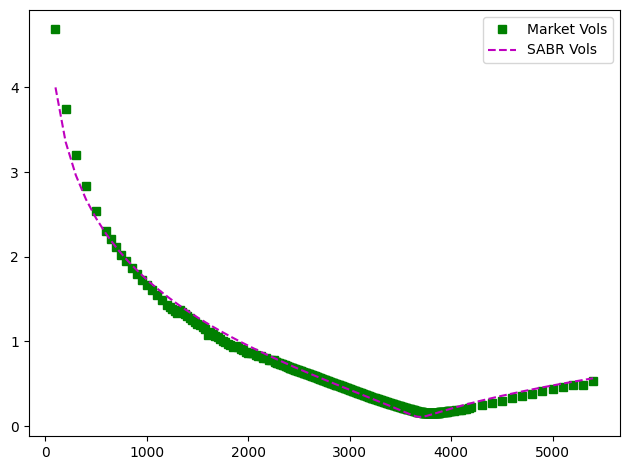

In [3]:
plt.figure(tight_layout=True)
plt.plot(strikes, df['impliedvol'], 'gs', label='Market Vols')
plt.plot(strikes, sabrvols, 'm--', label='SABR Vols')
plt.legend()
plt.show()